In [98]:
!pip install tqdm
import os
import numpy as np
import pandas as pd 
import scipy.io as sio
import cv2
import tqdm
import matplotlib.pyplot as plt 
import matplotlib.patches as patches

DATA_PATH = 'data/lizard/'

# 1. Carichiamo i file usando il percorso corretto (os.path.join)
images = np.load(os.path.join(DATA_PATH, 'images.npy'))
labels = np.load(os.path.join(DATA_PATH, 'labels.npy'))
patch_info = pd.read_csv(os.path.join(DATA_PATH, 'patch_info.csv'))

# 2. Ora procedi con la stampa dei conteggi (senza ripetere np.load)
print(f"--- RIEPILOGO DATASET LIZARD ---")
print(f"Numero totale di immagini: {images.shape[0]}")
print(f"Numero totale di labels:   {labels.shape[0]}") 

--- RIEPILOGO DATASET LIZARD ---
Numero totale di immagini: 4981
Numero totale di labels:   4981


In [99]:
df_lizard = patch_info['patch_info'].str.extract(r'([a-zA-Z]+)_(\d+)-(\d+)')
df_lizard.columns = ['source_dataset', 'case_id', 'patch_idx']
df_lizard['full_id'] = patch_info['patch_info']

def get_lizard_data_dict(idx, images_array, labels_array):
    # Canale 0: Mappa delle istanze (ID univoci per ogni nucleo)
    inst_map = labels[idx, :, :, 0].astype('int32')
    # Canale 1: Mappa delle classi (tipo di cellula)
    class_map = labels[idx, :, :, 1].astype('int32')
    nuclei_id = np.unique(inst_map)
    nuclei_id = nuclei_id[nuclei_id != 0]
    classes = []
    bboxes = []
    centroids = []

    for n_id in nuclei_id:
        # Troviamo i pixel di questo specifico nucleo
        coords = np.argwhere(inst_map == n_id) 
        
        # Bounding Box: [x_min, y_min, x_max, y_max]
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        bboxes.append([x_min, y_min, x_max, y_max])
        
        # Centroide
        y_c, x_c = coords.mean(axis=0)
        centroids.append([int(x_c), int(y_c)])
        
        # Classe (presa dalla mappa delle classi nel primo pixel utile)
        n_class = class_map[coords[0,0], coords[0,1]]
        classes.append(n_class)

    # Restituiamo il dizionario "stile Nuinsseg"
    return {
        'image': images[idx],
        'inst_map': inst_map,
        'nuclei_id': nuclei_id.tolist(),
        'classes': np.array(classes),
        'bboxs': np.array(bboxes),
        'centroids': np.array(centroids)
    } 
   
scelta_indice = 150

# CREA IL DIZIONARIO
dati_nuclei = get_lizard_data_dict(scelta_indice, images, labels)

# ORA HAI TUTTO ACCESSIBILE
print(f"Sto analizzando la patch: {df_lizard.iloc[scelta_indice]['full_id']}")
print(f"Provenienza: {df_lizard.iloc[scelta_indice]['source_dataset']}")
print(f"Numero di nuclei trovati: {len(dati_nuclei['nuclei_id'])}")

# Se vuoi vedere le classi dei primi 5 nuclei:
print(f"Classi: {dati_nuclei['classes'][:5]}")  

Sto analizzando la patch: crag_11-0014
Provenienza: crag
Numero di nuclei trovati: 139
Classi: [2 2 2 3 2]


In [100]:
# Mappatura ufficiale Lizard/CoNIC
mapping_classi = {
    1: "Neutrophil",    # Neutrofili (Infiammazione)
    2: "Epithelial",    # Epiteliali (Ghiandole/Tumore)
    3: "Lymphocyte",    # Linfociti (Risposta immunitaria)
    4: "Plasma",        # Plasmacellule
    5: "Eosinophil",    # Eosinofili
    6: "Connective"     # Connettivo/Stroma (Supporto)
}
# Supponiamo di avere i dati della patch 150
dati_patch = get_lizard_data_dict(150, images, labels)

# Trasformiamo la lista di numeri [2, 2, 3...] in nomi ["Epithelial", "Epithelial", "Lymphocyte"...]
nomi_nuclei = [mapping_classi[c] for c in dati_patch['classes']]

print(f"I primi 5 nuclei della patch sono: {nomi_nuclei[:5]}") 

I primi 5 nuclei della patch sono: ['Epithelial', 'Epithelial', 'Epithelial', 'Lymphocyte', 'Epithelial']


In [107]:
lista_immagini = []
lista_nuclei = []
totale = len(images)

for i in range(totale):
    # 1. Estraiamo i dati della patch i con la funzione creata
    dati = get_lizard_data_dict(i, images, labels)
    
    # 2. Info a livello di IMMAGINE (simile a df_images in Nuinsseg)
    img_info = {
        'patch_index': i,
        'inst_map' : df_lizard.iloc[i]['full_id'],
        'patch_name': df_lizard.iloc[i]['full_id'],
        'source': df_lizard.iloc[i]['source_dataset'],
        'case_id': df_lizard.iloc[i]['case_id'],
        'n_nuclei': len(dati['nuclei_id']),
        'R_mean': np.mean(dati['image'][:,:,0]),
        'G_mean': np.mean(dati['image'][:,:,1]),
        'B_mean': np.mean(dati['image'][:,:,2])
    }
    lista_immagini.append(img_info)
    
    # 3. Info a livello di NUCLEO (simile a df_nuclei in Nuinsseg)
    for j in range(len(dati['nuclei_id'])):
        nucleo_info = {
            'patch_index': i,
            'nucleo_id': dati['nuclei_id'][j],
            'classe': dati['classes'][j],
            'centroide_x': dati['centroids'][j][0],
            'centroide_y': dati['centroids'][j][1],
            'bbox': dati['bboxs'][j]
        }
        lista_nuclei.append(nucleo_info)

# Creazione dei DataFrame finali
df_images_lizard = pd.DataFrame(lista_immagini)
df_nuclei_lizard = pd.DataFrame(lista_nuclei) 



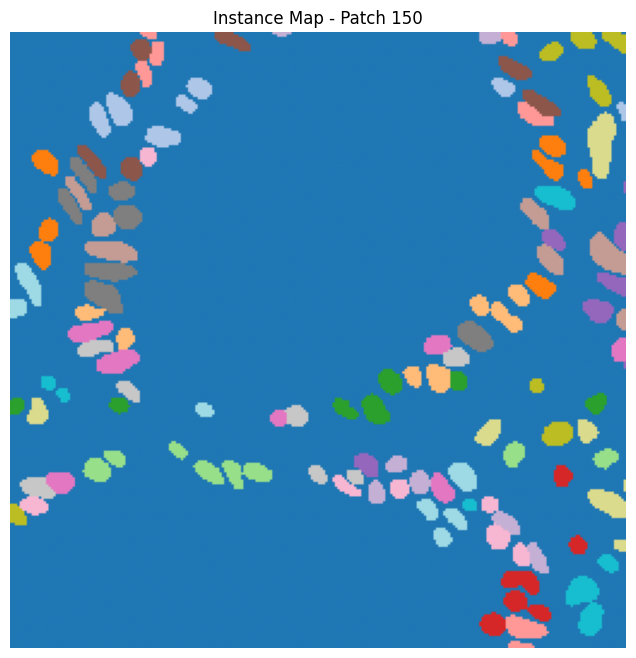

In [102]:
# 1. Definiamo l'INDICE (il numero della patch)
idx_da_vedere = 150 

# 2. Estraiamo il DIZIONARIO (il pacchetto dati)
dati_patch = get_lizard_data_dict(idx_da_vedere, images, labels)

# 3. Spacchettiamo gli array dal dizionario
inst_map = dati_patch['inst_map']
# (qui puoi spacchettare anche bboxs, classes, ecc. se ti servono)

# 4. Visualizzazione (Il tuo codice era perfetto qui!)
plt.figure(figsize=(8, 8))
plt.imshow(inst_map, cmap="tab20") 
plt.title(f"Instance Map - Patch {idx_da_vedere}")
plt.axis("off") 
plt.show() 

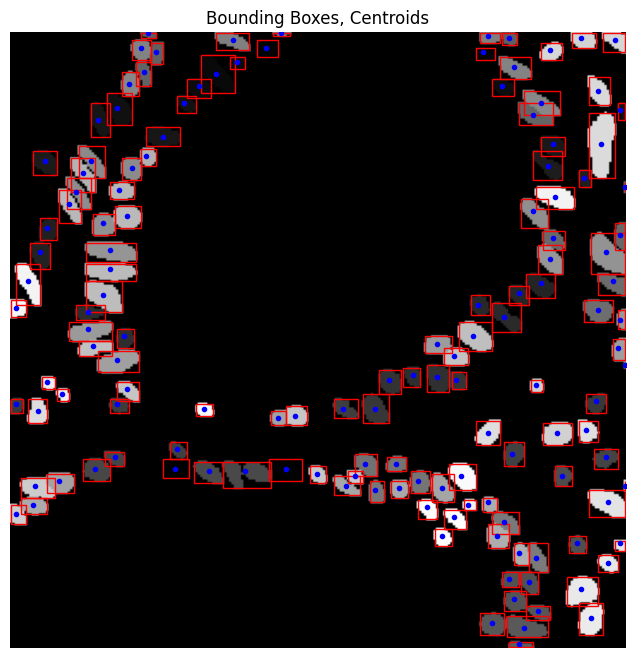

In [103]:
# 2. Overlay bounding boxes and centroids
fig, ax = plt.subplots(figsize=(8,8)) #è la finestra (il quadro), ax è la superficie dove disegni (la tela). Usiamo ax per aggiungere strati uno sopra l'altro
ax.imshow(inst_map, cmap="gray") #Carica la mappa dei nuclei come sfondo. Usiamo cmap="gray" (grigio) perché è neutro: i colori che aggiungeremo dopo (rosso, blu, giallo) 
    #risalteranno meglio su uno sfondo scuro e spento
inst_map = dati_patch['inst_map']
bboxs = dati_patch['bboxs']
centroids = dati_patch['centroids']
nuclei_id = dati_patch['nuclei_id']
for idx, nucleus_id in enumerate(nuclei_id): #i sto prendendo il numero di riga e il corrispondente id di cellule esistenti nel dataset
    #Se il tuo nuclei_id fosse [10, 25, 80]:
    #Al primo giro: idx = 0, nucleus_id = 10. Il codice userà bboxs[0] e centroids[0].
    #Al secondo giro: idx = 1, nucleus_id = 25. Il codice userà bboxs[1] e centroids[1].
    x1, y1, x2, y2 = bboxs[idx] 
    cx, cy = centroids[idx]   # Ordine: (x, y) -> Prendi il punto centrale esatto di quel nucleo specifico
    #I centroidi sono considerati punti geometrici, si usastandard matematico classico: prima la distanza orizzontale x e poi quella verticale (y)
      # 2. Calcolo dimensioni
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=1, edgecolor="r", facecolor="none") 
    # la funzione rect in input riceve rispettivamente (punto di partenza, larghezza (x2-x1) e altezza (y2-y1)) 
    #edgecolor="r": r sta per Red (Rosso). Disegna il contorno.
    #facecolor="none" dice di non colorare l'interno del rettangolo
    ax.add_patch(rect)

    ax.plot(cx, cy, "bo", markersize=3) #bo": Sta per Blue Object (un cerchietto blu). 
                                    #Mette un puntino sul centroide. Se il puntino blu finisce fuori dal rettangolo rosso, sai che c'è un errore nei tuoi dati
    ax.set_title("Bounding Boxes, Centroids")
    ax.axis("off")
plt.show() 

In [104]:
# CONTROLLO SE MASCHERE BINARIE
# 1. maschera di esempio 
indice = 2 
maschera = labels[indice] 

# 2. conotrollo valori unici
valori = np.unique(maschera)

print("--- ESITO DEL TEST ---")
print(f"I valori presenti nella maschera sono: {valori}")

# 3. Interpretazione automatica
if len(valori) == 2:
    print("Confermato: Il dataset è BINARIO (solo sfondo e nuclei).")
else:
    print(f"Il dataset è MULTICLASSE (contiene {len(valori)} tipi di etichette).") 

--- ESITO DEL TEST ---
I valori presenti nella maschera sono: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202]
Il dataset è MULTICLASSE (contiene 203 tipi di etichette).


In [105]:
# 1. Creazione della maschera binaria
# Ogni pixel > 0 diventa True (1), lo 0 resta False (0)
maschera_binaria = (inst_map > 0).astype(np.uint8)

# 2. Verifica rapida
print(f"Valori unici dopo la binarizzazione: {np.unique(maschera_binaria)}")
# Dovrebbe stampare: [0 1] 

Valori unici dopo la binarizzazione: [0 1]


In [108]:
totale = len(images)
data_images = []

for i in range(totale):
    # 1. Recuperiamo i dati della patch tramite la nostra funzione
    dati = get_lizard_data_dict(i, images, labels)
    
    img = dati['image']
    inst_map = dati['inst_map']
    
    # 2. CALCOLO NUCLEI E DENSITÀ
    # Non serve connectedComponents! nuclei_id contiene già l'elenco dei nuclei
    n_nuclei = len(dati['nuclei_id'])
    
    # Area della patch (256 * 256 = 65536)
    area_patch = img.shape[0] * img.shape[1]
    density = n_nuclei / area_patch
    # 3. STATISTICHE COLORE (RGB)
    # Calcoliamo media e deviazione standard per ogni canale
    R_mean, G_mean, B_mean = np.mean(img, axis=(0, 1))
    R_std, G_std, B_std = np.std(img, axis=(0, 1))

    # 4. SALVATAGGIO NEL DIZIONARIO
    # Usiamo df_lizard per recuperare il nome originale della patch
    patch_info = df_lizard.iloc[i]
    
    data_images.append({
        "patch_index": i,
        "image_id": patch_info['full_id'],
        "source_dataset": patch_info['source_dataset'],
        "nuclei_count": n_nuclei,
        "density": density,
        "R_mean": R_mean,
        "G_mean": G_mean,
        "B_mean": B_mean,
        "R_std": R_std,
        "G_std": G_std,
        "B_std": B_std
    })

# Creazione del DataFrame finale
df_images_lizard = pd.DataFrame(data_images) 

In [109]:
df_dataset = pd.DataFrame([{
    "num_images": len(images),
    "num_masks": len(labels),
    "mean_nuclei_per_image": df_images_lizard["nuclei_count"].mean(),
    "mean_density": df_images_lizard["density"].mean(),
    "R_mean_dataset": df_images_lizard["R_mean"].mean(),
    "G_mean_dataset": df_images_lizard["G_mean"].mean(),
    "B_mean_dataset": df_images_lizard["B_mean"].mean()
}])

print(df_dataset) 

   num_images  num_masks  mean_nuclei_per_image  mean_density  R_mean_dataset  \
0        4981       4981             114.406946      0.001746      194.968426   

   G_mean_dataset  B_mean_dataset  
0      154.255437      201.362713  


In [112]:
# NUMERI TOTALI NUCLEI E MEDIA NUCLEI PER IMMAGINE

print(f"Nuclei totali nel dataset:", df_images_lizard["nuclei_count"].sum())
print(f"Media di nuclei per immagine: ", df_images_lizard["nuclei_count"].mean()) 

Nuclei totali nel dataset: 569861
Media di nuclei per immagine:  114.40694639630597


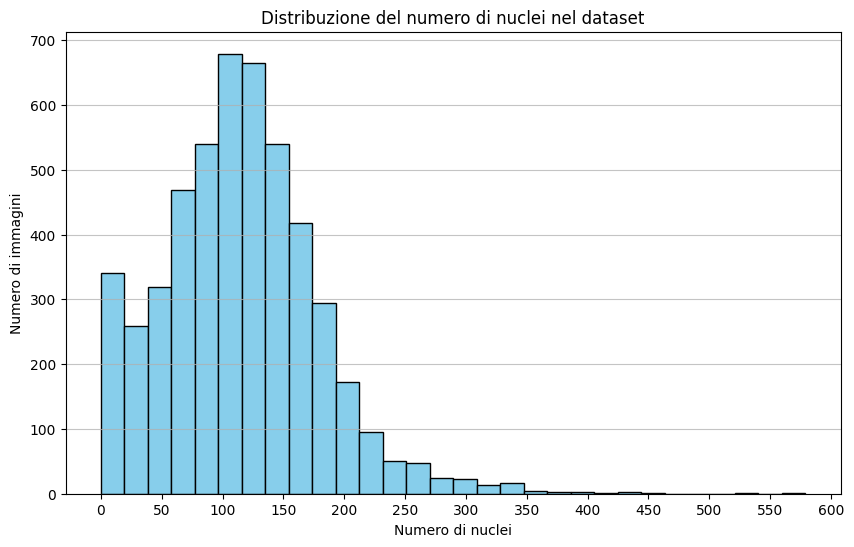

In [113]:
# GRAFICO DISTRIBUZIONE NUCLEI NELLE IMMAGINI

plt.figure(figsize=(10, 6))
plt.hist(df_images_lizard["nuclei_count"], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.xticks(np.arange(0, df_images_lizard["nuclei_count"].max() + 50, 50))
plt.grid(axis='y', alpha=0.75)
plt.savefig("hist_images_VS_nuclei_lizard.png", dpi=300)

plt.show()  

In [114]:
# DENSITà MEDIA E DEVIAZIONE STANDARD

print(f"densità media:", df_images_lizard["density"].mean())
print(f"deviazione standard: ", df_images_lizard["density"].std() ) 

densità media: 0.0017457114623459773
deviazione standard:  0.0009747577108590748


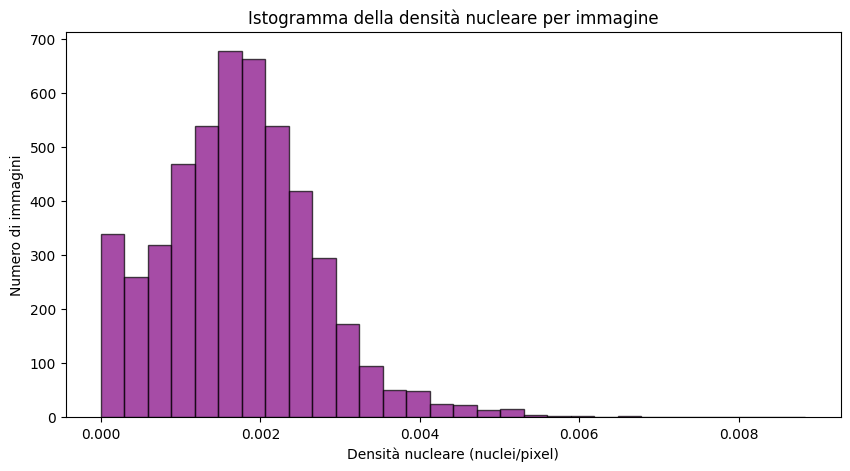

In [115]:
# ISOGRAMMA DENSITà NUCLEARE (NUCLEO/PIXEL)

plt.figure(figsize=(10,5))
plt.hist(df_images_lizard["density"], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.savefig("hist_images_VS_density_lizard.png", dpi=300)

plt.show() 

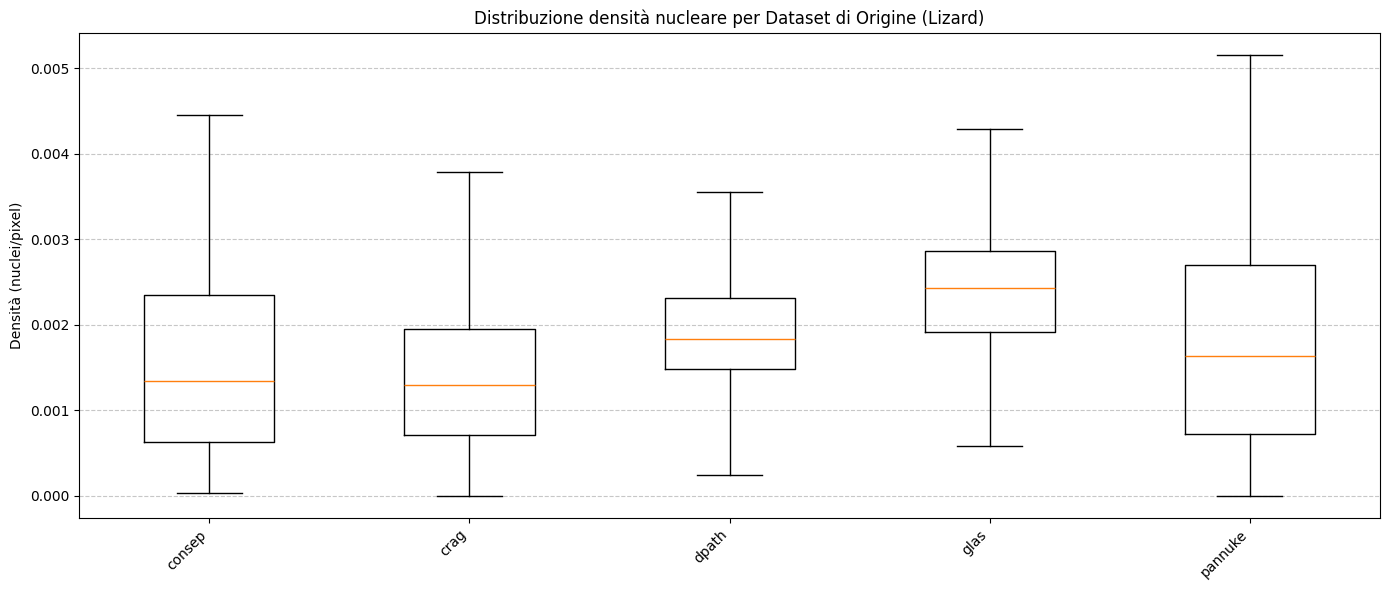

In [116]:
# 1. PREPARAZIONE DATI
# Recuperiamo i nomi unici dei dataset sorgente
sources = df_images_lizard['source_dataset'].unique()

# Creiamo la lista di liste (una lista di densità per ogni source)
all_densities = [df_images_lizard[df_images_lizard['source_dataset'] == s]['density'].values for s in sources]

# 2. CREAZIONE DEL GRAFICO
plt.figure(figsize=(14,6))

# Creiamo il boxplot
# Nota: usiamo 'sources' come etichette per l'asse X
plt.boxplot(all_densities, tick_labels=sources, showfliers=False)

# 3. ESTETICA E SALVATAGGIO
plt.xticks(rotation=45, ha='right')
plt.title("Distribuzione densità nucleare per Dataset di Origine (Lizard)")
plt.ylabel("Densità (nuclei/pixel)")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Aggiunge una griglia leggera per leggere meglio i valori
plt.tight_layout()

# Salviamo il file specifico per Lizard
plt.savefig("boxplot_density_Lizard_by_source.png", dpi=300) 
plt.show() 

In [117]:
# Calcoliamo le medie globali partendo dal DataFrame che abbiamo creato prima
R_mean_global = df_images_lizard["R_mean"].mean()
G_mean_global = df_images_lizard["G_mean"].mean()
B_mean_global = df_images_lizard["B_mean"].mean()

# Per la deviazione standard globale, la via più corretta è calcolarla 
# dai valori medi (approssimazione valida per la tesi)
R_std_global = df_images_lizard["R_std"].mean()
G_std_global = df_images_lizard["G_std"].mean()
B_std_global = df_images_lizard["B_std"].mean()

print("📊 STATISTICHE RGB GLOBALI (da DataFrame)\n")
print(f"🔴 Red   -> Media: {R_mean_global:.2f} | Dev.Std: {R_std_global:.2f}")
print(f"🟢 Green -> Media: {G_mean_global:.2f} | Dev.Std: {G_std_global:.2f}")
print(f"🔵 Blue  -> Media: {B_mean_global:.2f} | Dev.Std: {B_std_global:.2f}") 

📊 STATISTICHE RGB GLOBALI (da DataFrame)

🔴 Red   -> Media: 194.97 | Dev.Std: 34.09
🟢 Green -> Media: 154.26 | Dev.Std: 40.67
🔵 Blue  -> Media: 201.36 | Dev.Std: 25.58


In [119]:
# Raggruppiamo per 'source_dataset' (la colonna che hai creato nel loop)
stats_per_sub = df_images_lizard.groupby("source_dataset").agg({
    "R_mean": "mean",
    "G_mean": "mean",
    "B_mean": "mean",
    "R_std": "mean",
    "G_std": "mean",
    "B_std": "mean",
    "nuclei_count": "mean", # Utile per vedere chi ha più nuclei mediamente
    "density": "mean"
}).reset_index()

print("📊 STATISTICHE MEDIE PER SOTTODATASET (Lizard)")
display(stats_per_sub.round(3))

# Salva la tabella per la tesi
stats_per_sub.to_csv("lizard_statistics_by_source.csv", index=False) 

📊 STATISTICHE MEDIE PER SOTTODATASET (Lizard)


,source_dataset,R_mean,G_mean,B_mean,R_std,G_std,B_std,nuclei_count,density
0,consep,214.446,182.117,221.364,31.942,41.220,23.270,103.047,0.002
1,crag,217.328,189.697,220.995,26.276,33.977,20.542,91.561,0.001
2,dpath,162.966,113.917,174.598,42.594,45.593,31.279,125.547,0.002
3,glas,201.050,137.167,202.806,37.110,48.791,26.790,159.960,0.002
4,pannuke,199.795,164.302,206.927,40.523,48.264,31.533,126.411,0.002


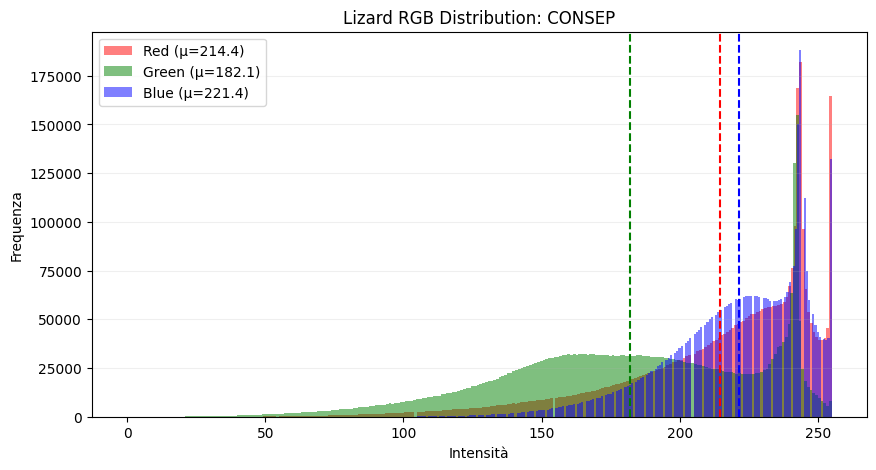

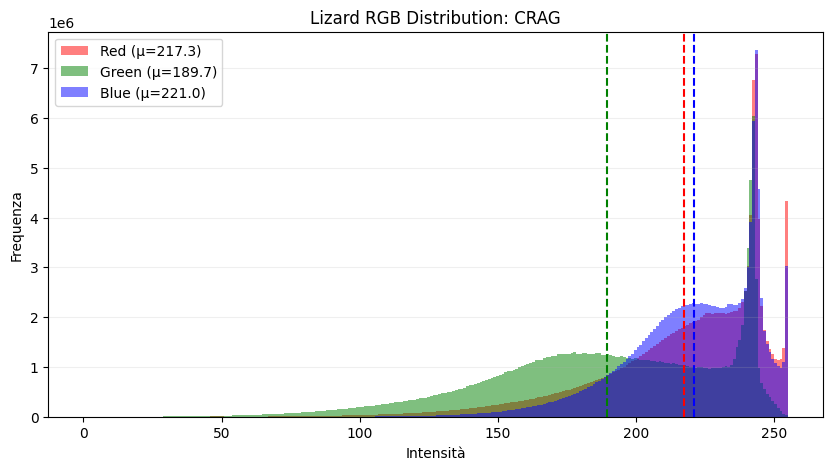

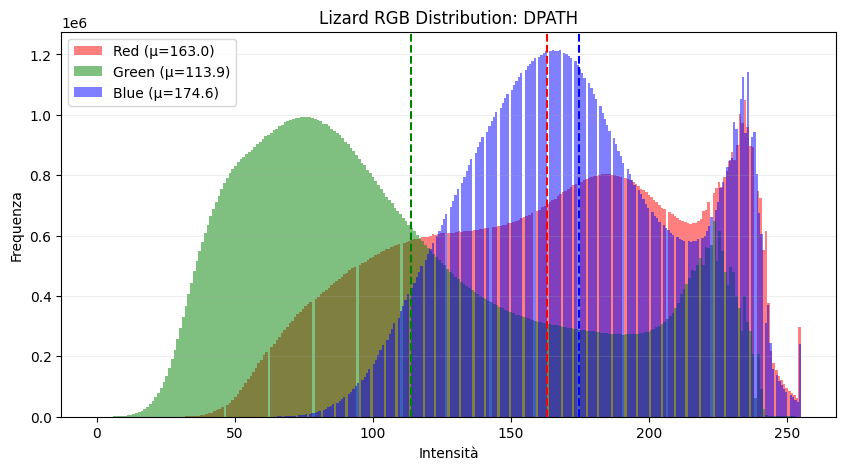

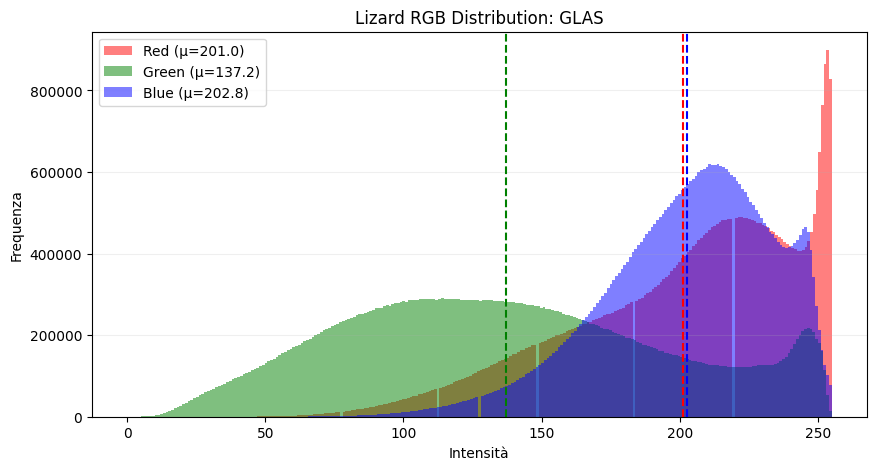

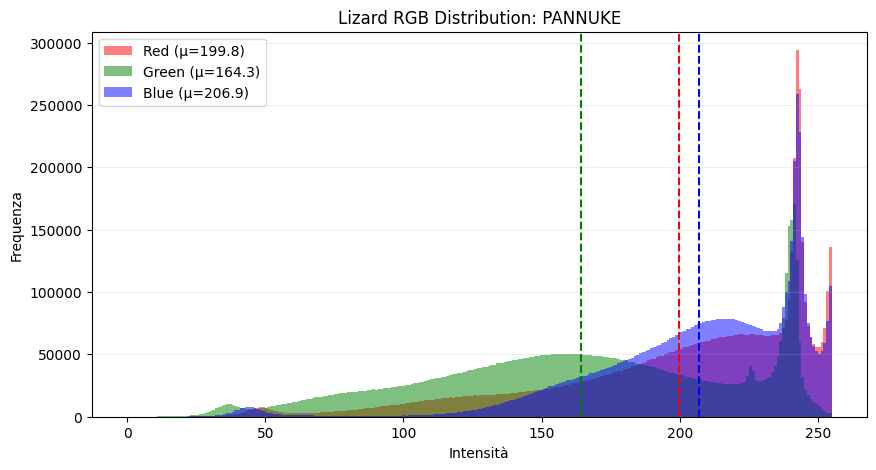

In [121]:
unique_sources = df_images_lizard["source_dataset"].unique()

for source in unique_sources:
    # 1. Troviamo gli indici delle patch appartenenti a questo dataset
    indices = df_images_lizard[df_images_lizard["source_dataset"] == source].index.tolist()
    
    # Selezioniamo le immagini corrispondenti
    sub_images = images[indices]
    
    # 2. Campionamento pixel (1 ogni 500 per velocità)
    R_vals = sub_images[:, :, :, 0].flatten()
    G_vals = sub_images[:, :, :, 1].flatten()
    B_vals = sub_images[:, :, :, 2].flatten()
    # Medie per le linee tratteggiate
    rm, gm, bm = R_vals.mean(), G_vals.mean(), B_vals.mean()

    # 3. Plot
    plt.figure(figsize=(10, 5))
    plt.hist(R_vals, bins=256, color='red', alpha=0.5, label=f'Red (μ={rm:.1f})')
    plt.hist(G_vals, bins=256, color='green', alpha=0.5, label=f'Green (μ={gm:.1f})')
    plt.hist(B_vals, bins=256, color='blue', alpha=0.5, label=f'Blue (μ={bm:.1f})')
    
    plt.axvline(rm, color='red', linestyle='--')
    plt.axvline(gm, color='green', linestyle='--')
    plt.axvline(bm, color='blue', linestyle='--')
    
    plt.title(f"Lizard RGB Distribution: {source.upper()}", fontsize=12)
    plt.xlabel("Intensità")
    plt.ylabel("Frequenza")
    plt.legend()
    plt.grid(axis='y', alpha=0.2)
    plt.show()  

📊 ANALISI DESCRITTIVA DEI PIXEL (Lizard Dataset)
                Red         Green          Blue
count  3.264348e+08  3.264348e+08  3.264348e+08
mean   1.949684e+02  1.542554e+02  2.013627e+02
std    4.799916e+01  6.223776e+01  3.751095e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.670000e+02  1.020000e+02  1.760000e+02
50%    2.080000e+02  1.610000e+02  2.100000e+02
75%    2.340000e+02  2.080000e+02  2.320000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


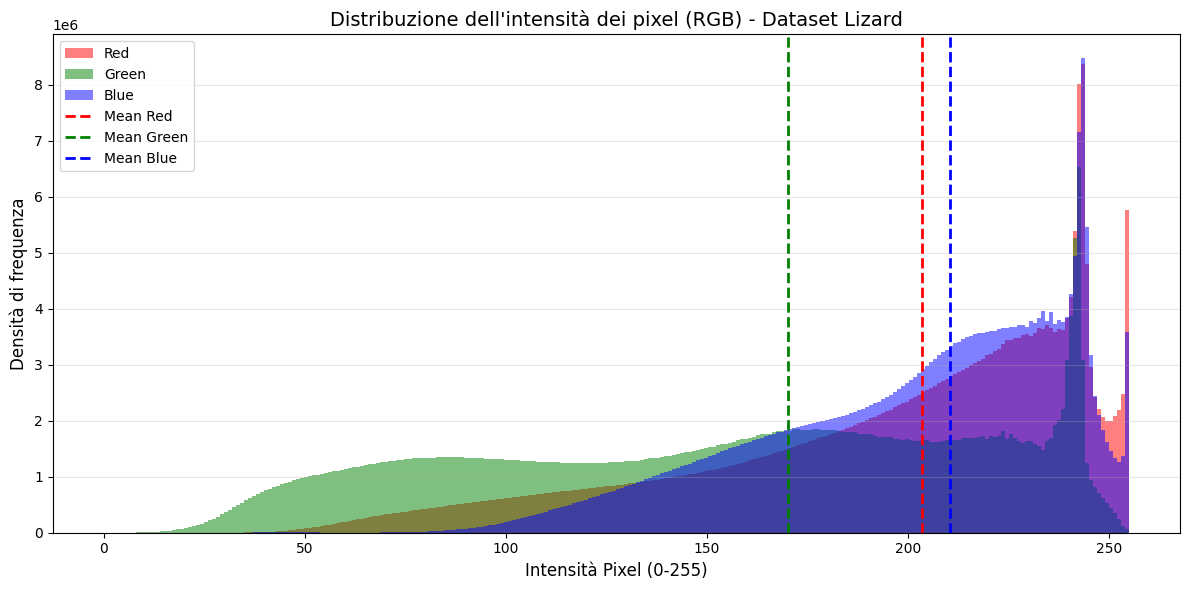

In [122]:
# 1. CAMPIONAMENTO DEI PIXEL (per evitare MemoryError)
# Prendiamo un pixel ogni 500 per avere una distribuzione precisa ma leggera
# images ha forma [4981, 256, 256, 3]
R_values = images[:, :, :, 0].flatten()
G_values = images[:, :, :, 1].flatten()
B_values = images[:, :, :, 2].flatten()

# 2. STATISTICHE DESCRITTIVE
df_rgb = pd.DataFrame({
    'Red': R_values,
    'Green': G_values,
    'Blue': B_values
})

print("📊 ANALISI DESCRITTIVA DEI PIXEL (Lizard Dataset)")
print(df_rgb.describe())

# 3. VISUALIZZAZIONE ISTOGRAMMA
plt.figure(figsize=(12, 6))

# Usiamo bins=256 perché i valori dei pixel vanno da 0 a 255
plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

# Aggiungiamo le linee delle medie (usando i valori globali calcolati prima)
plt.axvline(R_mean, color='red', linestyle='dashed', linewidth=2, label='Mean Red')
plt.axvline(G_mean, color='green', linestyle='dashed', linewidth=2, label='Mean Green')
plt.axvline(B_mean, color='blue', linestyle='dashed',linewidth=2, label='Mean Blue')
plt.title("Distribuzione dell'intensità dei pixel (RGB) - Dataset Lizard", fontsize=14)
plt.xlabel("Intensità Pixel (0-255)", fontsize=12)
plt.ylabel("Densità di frequenza", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3) 

# 4. SALVATAGGIO
plt.tight_layout()
plt.savefig("hist_RGB_distribution_Lizard.png", dpi=300)  
plt.show() 

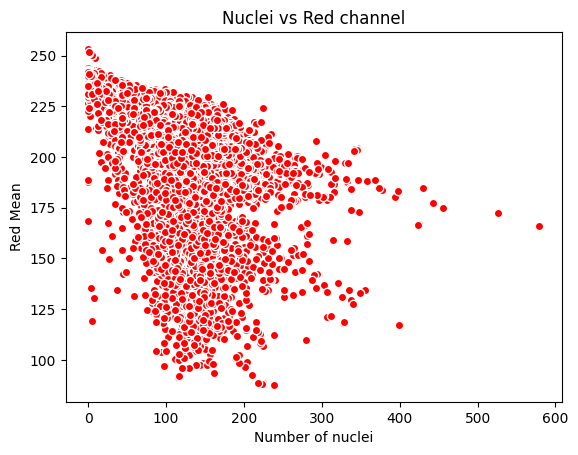

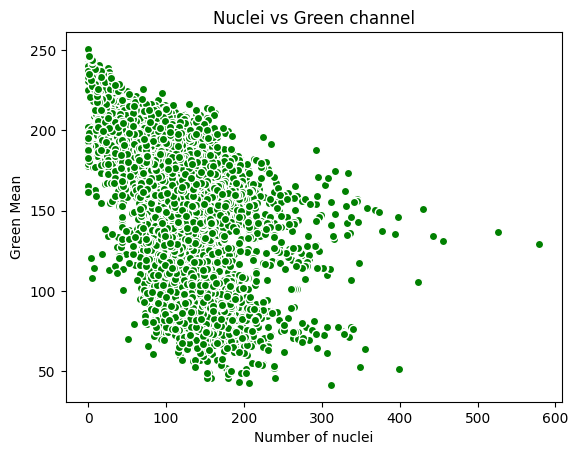

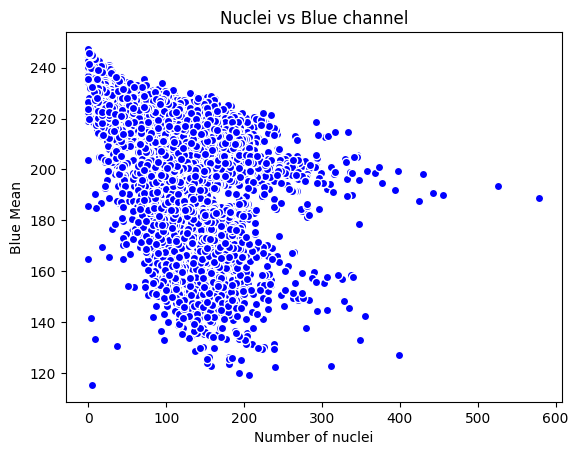

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_images_lizard["nuclei_count"], df_images_lizard["R_mean"], edgecolor='white', color= 'red')
plt.xlabel("Number of nuclei")
plt.ylabel("Red Mean")
plt.title("Nuclei vs Red channel")
plt.savefig("scatter_nuclei_VS_red_Lizard.png", dpi=300)

plt.show()

plt.figure()
plt.scatter(df_images_lizard["nuclei_count"], df_images_lizard["G_mean"], edgecolor='white', color= 'green')
plt.xlabel("Number of nuclei")
plt.ylabel("Green Mean")
plt.title("Nuclei vs Green channel")
plt.savefig("scatter_nuclei_VS_green_Lizard.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df_images_lizard["nuclei_count"], df_images_lizard["B_mean"], edgecolor='white', color= 'blue')
plt.xlabel("Number of nuclei")
plt.ylabel("Blue Mean")
plt.title("Nuclei vs Blue channel")
plt.savefig("scatter_nuclei_VS_blue_Lizard.png", dpi=300)
plt.show() 

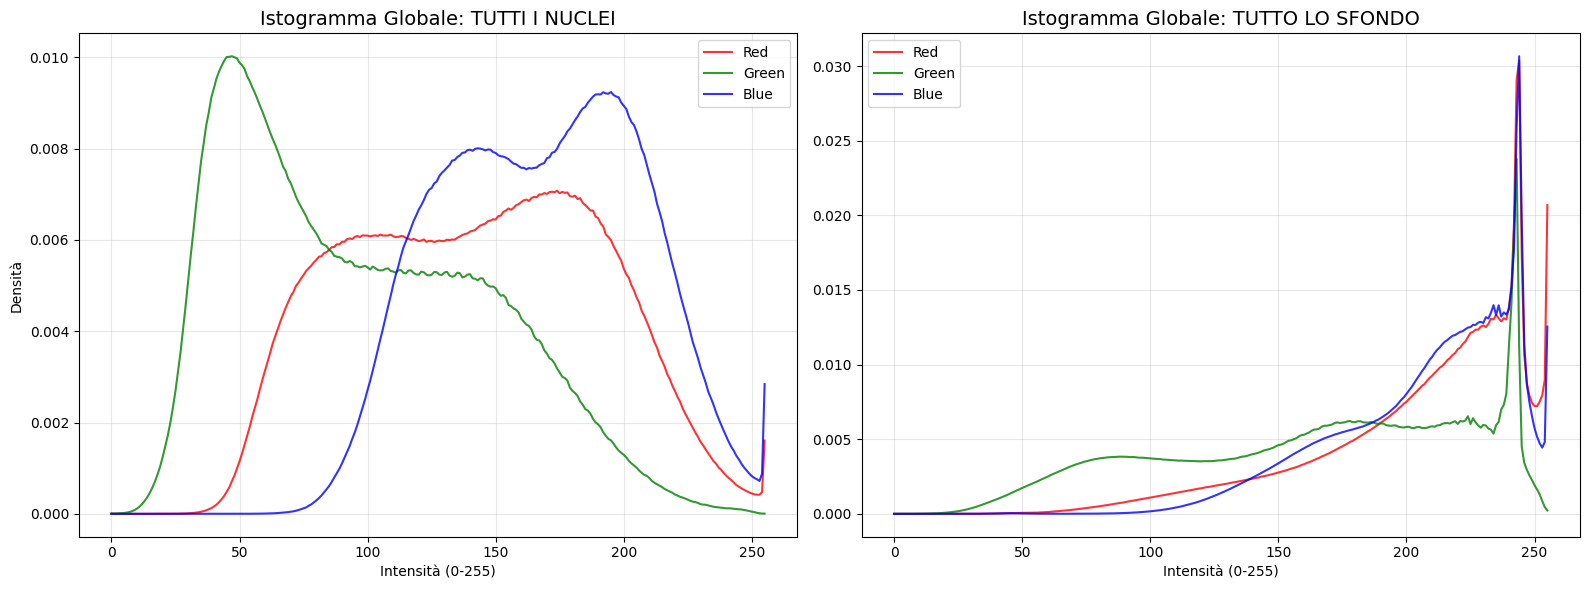

In [124]:
hist_nuclei = np.zeros((256, 3)) 
hist_bg = np.zeros((256, 3))
for i in range(len(images)):
    img = images[i]
    
    # Prendiamo solo il primo canale (indice 0) della maschera
    # labels[i] è (256, 256, 2) -> noi prendiamo (256, 256)
    mask = labels[i][:, :, 0] 
    
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    for ch in range(3):
        canale_corrente = img[:, :, ch]
        
        # Ora le dimensioni combaceranno perfettamente: (256, 256)
        hist_nuclei[:, ch] += np.histogram(canale_corrente[is_nucleus], bins=256, range=(0, 256))[0]
        hist_bg[:, ch] += np.histogram(canale_corrente[is_bg], bins=256, range=(0, 256))[0]
# 2. CREAZIONE DEL GRAFICO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colori = ['red', 'green', 'blue']
etichette = ['Red', 'Green', 'Blue']

# Normalizziamo gli istogrammi (per trasformarli in densità come prima)
# Somma totale dei pixel per nuclei e sfondo
total_n = hist_nuclei.sum(axis=0)[0] # Usiamo il canale R come riferimento per il totale
total_b = hist_bg.sum(axis=0)[0]
for ch in range(3):
    # Plot Nuclei
    ax1.plot(hist_nuclei[:, ch] / total_n, color=colori[ch], label=etichette[ch], alpha=0.8)
    # Plot Sfondo
    ax2.plot(hist_bg[:, ch] / total_b, color=colori[ch], label=etichette[ch], alpha=0.8)

# Estetica ax1 (Nuclei)
ax1.set_title("Istogramma Globale: TUTTI I NUCLEI", fontsize=14)
ax1.set_xlabel("Intensità (0-255)")
ax1.set_ylabel("Densità")
ax1.legend()
ax1.grid(alpha=0.3)

# Estetica ax2 (Sfondo)
ax2.set_title("Istogramma Globale: TUTTO LO SFONDO", fontsize=14)
ax2.set_xlabel("Intensità (0-255)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lizard_TUTTI_nuclei_vs_bg.png", dpi=300)
plt.show() 

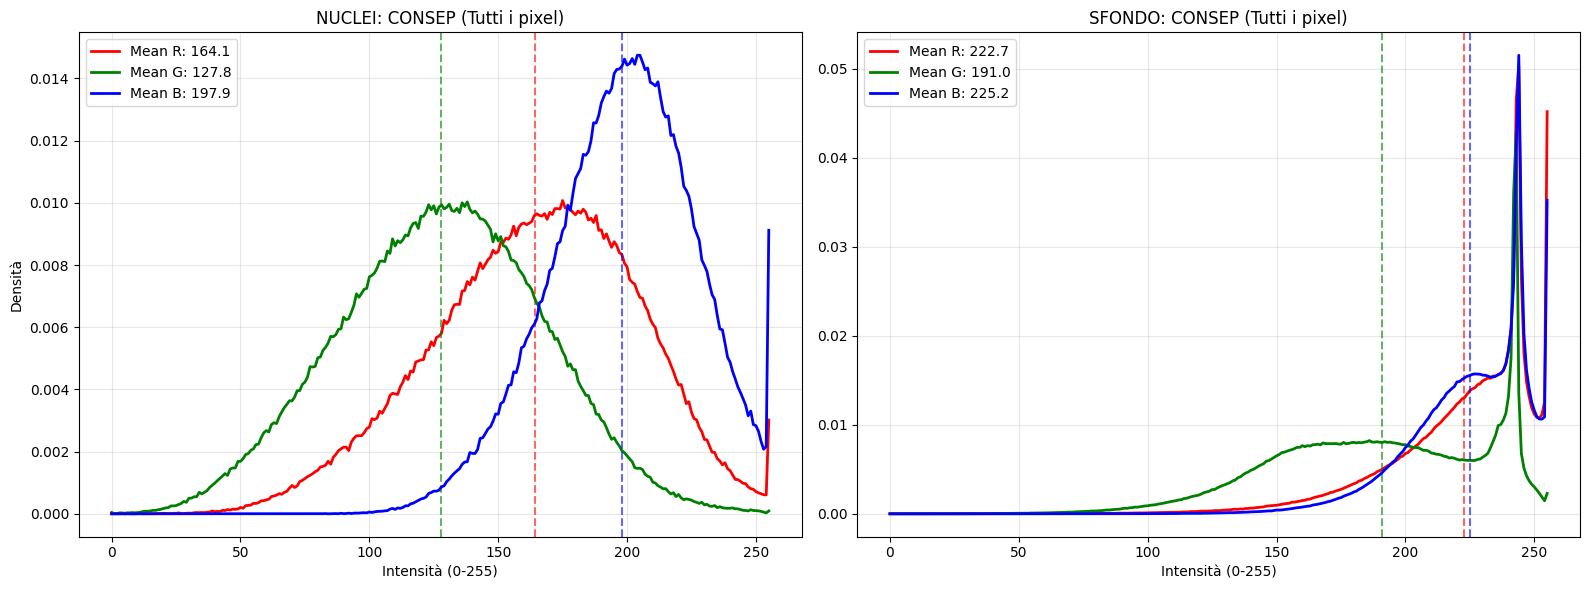

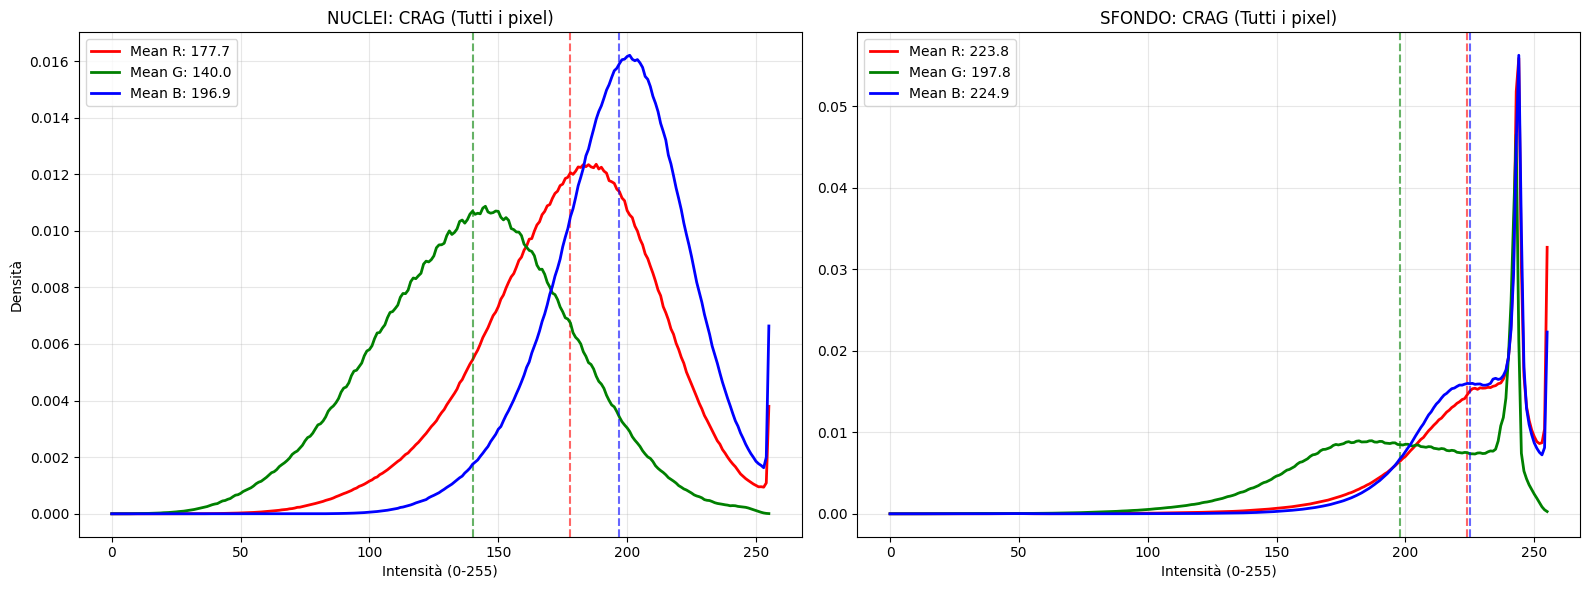

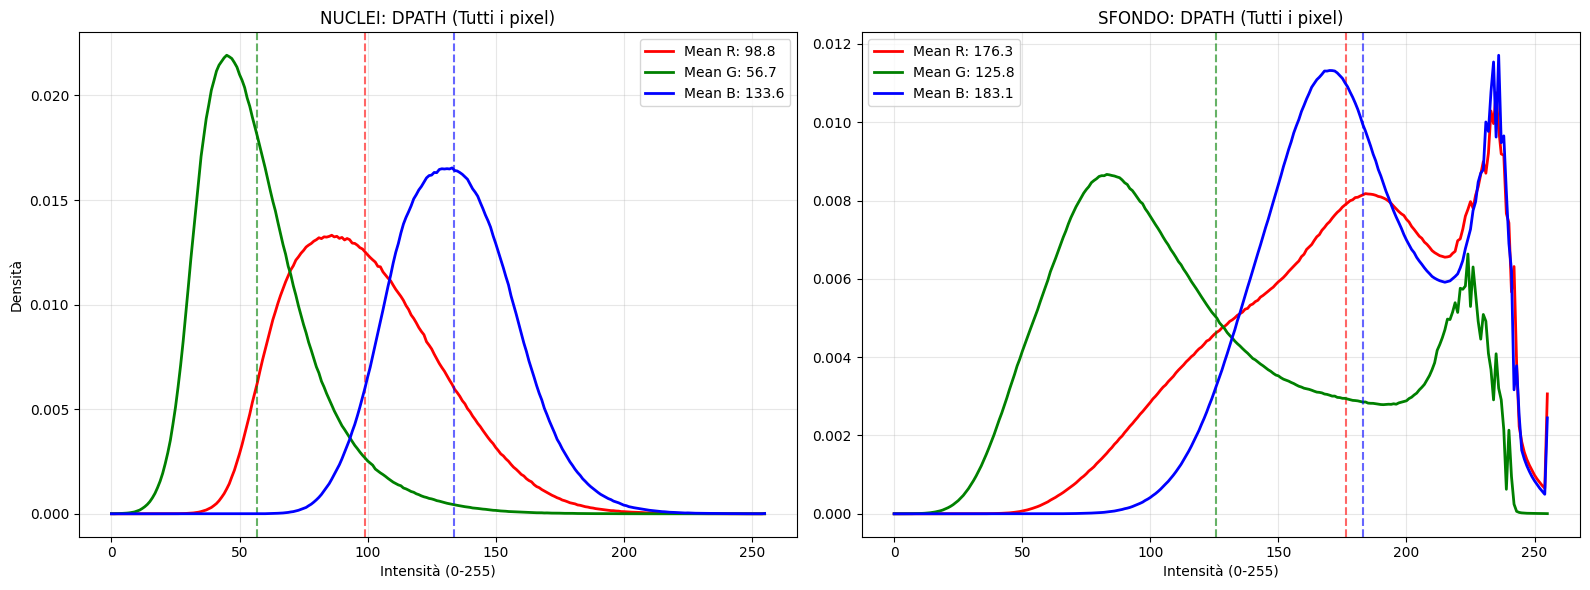

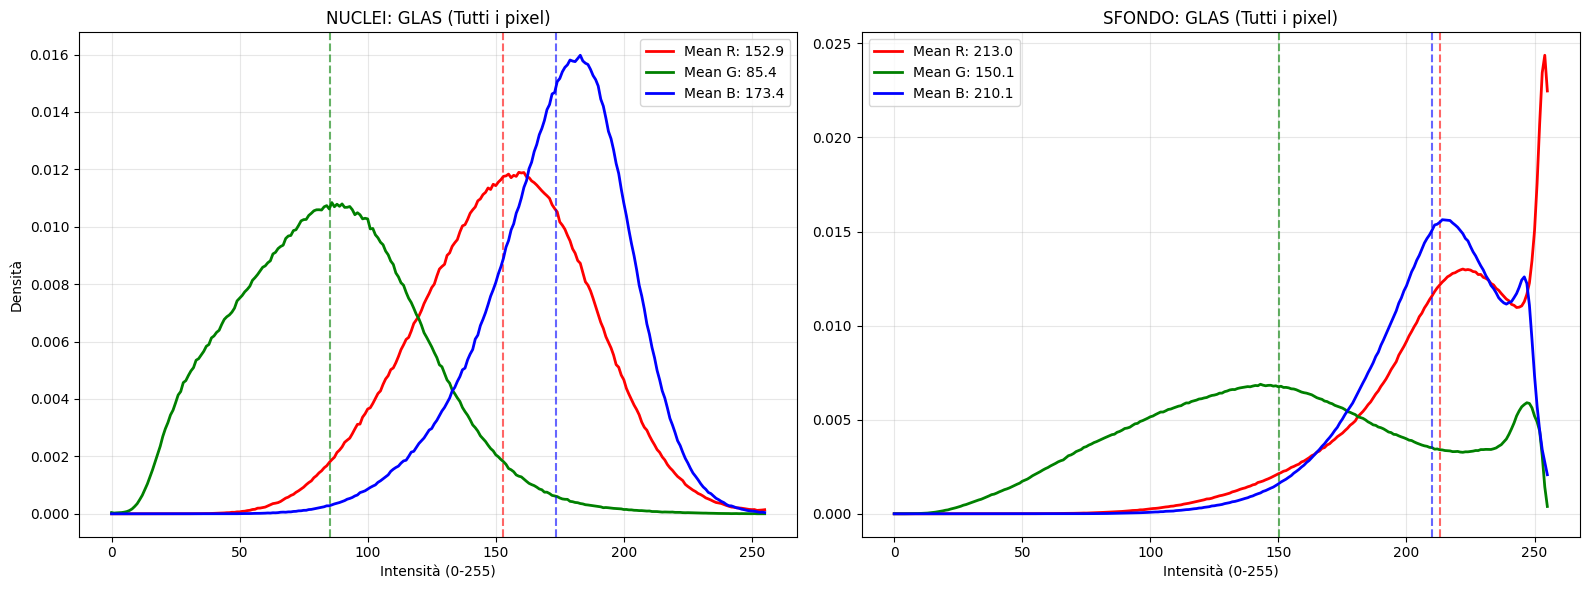

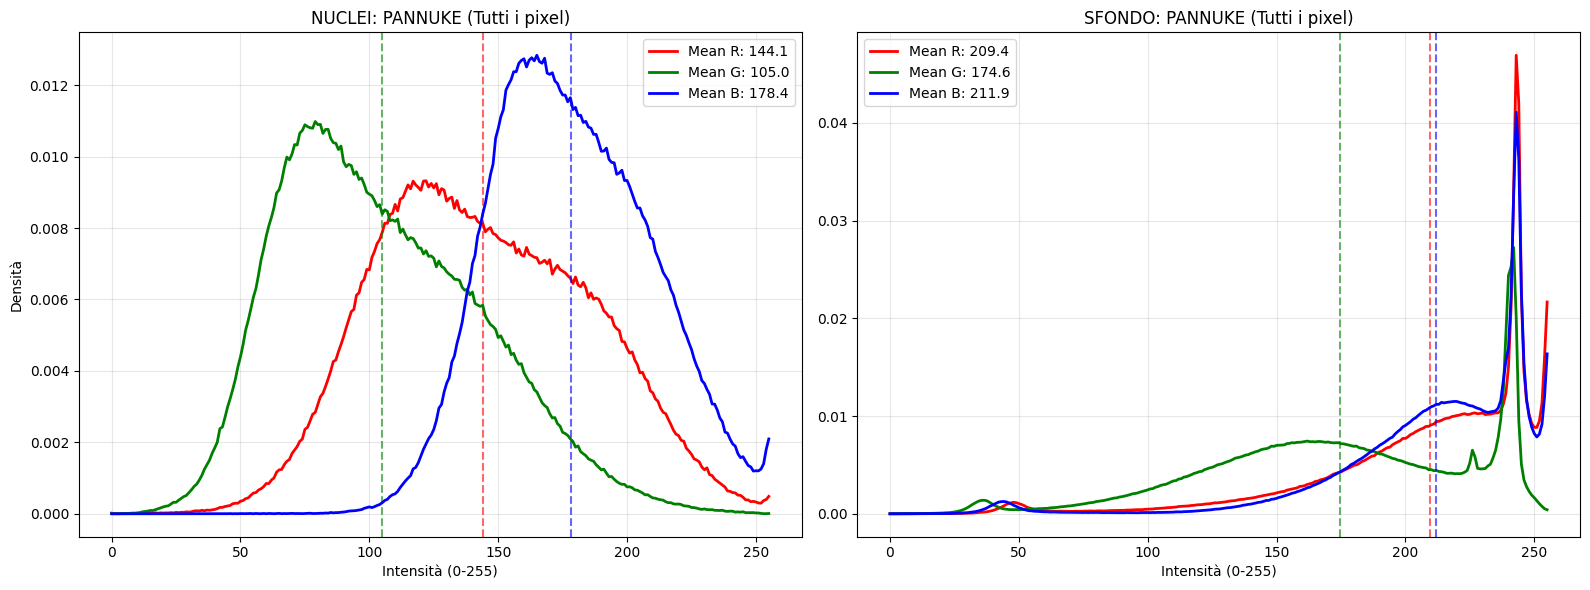

In [128]:
# 1. Inizializziamo un dizionario di istogrammi
# Ogni sottodataset avrà una matrice [256 livelli, 3 canali] per Nuclei e una per Sfondo
unique_sources = df_images_lizard["source_dataset"].unique()
hist_data = {source: {
    'nuclei': np.zeros((256, 3)), 
    'bg': np.zeros((256, 3))
} for source in unique_sources}

# 2. Ciclo su TUTTE le immagini
for i in range(len(df_images_lizard)):
    # Recuperiamo info e dati
    info = df_images_lizard.iloc[i]
    source = info["source_dataset"]
    idx = int(info["patch_index"])
    
    # Usiamo la tua funzione fidata
    dati = get_lizard_data_dict(idx, images, labels)
    img = dati['image']
    mask = dati['inst_map']
    
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    for ch in range(3):
        canal_pixel = img[:, :, ch]
        
        # Calcoliamo l'istogramma di TUTTI i pixel di questa immagine
        # nuclei
        if np.any(is_nucleus):
            h_n = np.histogram(canal_pixel[is_nucleus], bins=256, range=(0, 256))[0]
            hist_data[source]['nuclei'][:, ch] += h_n
            
        # sfondo
        if np.any(is_bg):
            h_b = np.histogram(canal_pixel[is_bg], bins=256, range=(0, 256))[0]
            hist_data[source]['bg'][:, ch] += h_b

# --- GENERAZIONE DEI GRAFICI PER IL SOTTODATASET CORRENTE ---
x_axis = np.arange(256)
colors = ['red', 'green', 'blue']

for source in unique_sources:
    # Creiamo una figura con due grafici (Nuclei e Sfondo) per il sottodataset corrente
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- PLOT NUCLEI ---
    h_n = hist_data[source]['nuclei']
    for ch in range(3):
        total_n = h_n[:, ch].sum()
        if total_n > 0:
            # Calcolo media reale pesata
            mean_val = np.average(x_axis, weights=h_n[:, ch])
            # Plot della distribuzione normalizzata
            ax1.plot(x_axis, h_n[:, ch] / total_n, color=colors[ch], lw=2, 
                     label=f'Mean {colors[ch][0].upper()}: {mean_val:.1f}')
            ax1.axvline(mean_val, color=colors[ch], linestyle='--', alpha=0.6)
    
    ax1.set_title(f"NUCLEI: {source.upper()} (Tutti i pixel)")
    ax1.set_xlabel("Intensità (0-255)")
    ax1.set_ylabel("Densità")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # --- PLOT SFONDO ---
    h_b = hist_data[source]['bg']
    for ch in range(3):
        total_b = h_b[:, ch].sum()
        if total_b > 0:
            mean_val_b = np.average(x_axis, weights=h_b[:, ch])
            ax2.plot(x_axis, h_b[:, ch] / total_b, color=colors[ch], lw=2, 
                     label=f'Mean {colors[ch][0].upper()}: {mean_val_b:.1f}')
            ax2.axvline(mean_val_b, color=colors[ch], linestyle='--', alpha=0.6)

    ax2.set_title(f"SFONDO: {source.upper()} (Tutti i pixel)")
    ax2.set_xlabel("Intensità (0-255)")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show() 
